# 第二章：勒索软件检测模型构建

本章使用 MindSpore 构建 CNN 勒索软件检测模型，完成数据读取、特征处理、模型训练与结果评估。

## 目录约定

- 将输入数据 `Ransomware.csv` 放入本章 `src/`。
- 运行生成的模型权重和评估结果统一保存到本章 `answer/`。
- 请在下方继续运行章节实践单元完成章节实践。


## 实验2章节实践：勒索软件检测模型构建

在这一节中，你将使用 MindSpore 构建一个勒索软件检测 CNN 模型：读取 PE 文件静态特征数据，完成缺失值处理、标签语义确认、特征标准化、模型训练与测试集评估。

实验目标：使用 CNN 模型识别勒索软件行为特征，实现数据预处理、标签编码和训练流程。


## 一、使用说明

运行前请先完成实验1的环境检查，并确认 `Ransomware.csv` 已放在本章 `src/` 目录下。按顺序运行全部单元即可完成模型构建；模型权重和评估结果统一写入本章 `answer/`。默认 `cloud_live` 配置会抽取 30000 条样本并训练 8 epoch；如果你需要完整训练，可在启动 Notebook 前设置环境变量 `ONSITE_DEMO_PROFILE=full`。

运行后重点观察三个结果：

- `accuracy`：整体分类准确率。
- `ransomware_recall`：勒索软件样本召回率，反映漏报风险。
- `confusion_matrix`：合法软件与勒索软件之间的误判结构。


## 二、导入依赖与运行环境配置


In [4]:
import os
import json
import random
import warnings
from pathlib import Path

os.environ.setdefault("GLOG_v", "3")
os.environ.setdefault("PYTHONWARNINGS", "ignore")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import mindspore as ms
import mindspore.dataset as ds
import mindspore.nn as nn
import mindspore.ops as ops

try:
    from IPython.display import display
except Exception:
    display = print
# 通过 ONSITE_DEMO_PROFILE 控制样本量和训练轮次。
RUN_PROFILE = os.environ.get("ONSITE_DEMO_PROFILE", "cloud_live").strip().lower()
PROFILE_SETTINGS = {
    "fast": {"max_samples": 8000, "epochs": 3, "batch_size": 256},
    "cloud_live": {"max_samples": 30000, "epochs": 8, "batch_size": 256},
    "full": {"max_samples": None, "epochs": 15, "batch_size": 256},
}
if RUN_PROFILE not in PROFILE_SETTINGS:
    raise RuntimeError(f"Unsupported ONSITE_DEMO_PROFILE: {RUN_PROFILE}")

SETTINGS = PROFILE_SETTINGS[RUN_PROFILE]

# 输入资源放在 src/；所有运行产物统一写入 answer/。
CURRENT_DIR = Path.cwd().resolve()
# 目录结构已扁平化：notebook 与 src/、answer/、images/ 同级
chapter_candidates = [
    CURRENT_DIR,
    CURRENT_DIR / "01_threat_detect",
]
CHAPTER_DIR = next((path for path in chapter_candidates if (path / "src").is_dir()), None)
if CHAPTER_DIR is None:
    raise FileNotFoundError("未找到课程目录（需包含 src/），请从课程目录打开 Notebook。")
PROJECT_ROOT = CHAPTER_DIR
DATA_DIR = CHAPTER_DIR / "src"
IMAGE_DIR = CHAPTER_DIR / "images"
OUTPUT_DIR = CHAPTER_DIR / "answer"
CKPT_DIR = OUTPUT_DIR
for path in (DATA_DIR, IMAGE_DIR, OUTPUT_DIR):
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
PREFERRED_DEVICE = os.environ.get("MS_DEVICE_TARGET", "Ascend")
DEVICE_ID = int(os.environ.get("DEVICE_ID", "0"))

# 固定随机种子，减少每次运行结果的波动。
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    ms.set_seed(seed)
    ds.config.set_seed(seed)

# 优先使用 Ascend；不可用时自动回退到 GPU 或 CPU。
def configure_mindspore_device(preferred="Ascend"):
    candidates = [preferred]
    for item in ["Ascend", "GPU", "CPU"]:
        if item not in candidates:
            candidates.append(item)
    errors = {}
    for device in candidates:
        try:
            ms.set_context(mode=ms.PYNATIVE_MODE, device_target=device)
            if device in {"Ascend", "GPU"}:
                try:
                    ms.set_context(device_id=DEVICE_ID)
                except Exception:
                    pass
            _ = ms.Tensor(np.ones((1,), dtype=np.float32))
            return device, errors
        except Exception as exc:
            errors[device] = repr(exc)
    raise RuntimeError(f"MindSpore 后端初始化失败：{errors}")

set_seed(SEED)
ACTUAL_DEVICE, DEVICE_ERRORS = configure_mindspore_device(PREFERRED_DEVICE)

print("=" * 70)
print("运行配置")
print("profile:", RUN_PROFILE, SETTINGS)
print("MindSpore 版本:", getattr(ms, "__version__", "unknown"))
print("当前后端:", ACTUAL_DEVICE)
if DEVICE_ERRORS:
    print("后端回退记录:", DEVICE_ERRORS)



运行配置
profile: cloud_live {'max_samples': 30000, 'epochs': 8, 'batch_size': 256}
MindSpore 版本: 2.7.2
当前后端: Ascend


## 三、读取勒索软件特征数据


In [5]:
# 数据集获取：若 src/ 下缺少 Ransomware.csv，则从指定地址下载。
# TODO: 在下方 DATASET_URLS 中填入实际下载地址（网盘直链或 HTTP 链接）后重运行本单元。
import urllib.request

DATASET_URLS = {
    "Ransomware.csv": "",  # TODO: 填入 Ransomware.csv 的下载地址
}


def _download_progress(block_num, block_size, total_size):
    downloaded = block_num * block_size
    if total_size > 0 and block_num % 100 == 0:
        pct = min(downloaded / total_size * 100, 100)
        print(f"  {downloaded / 1e6:.1f} / {total_size / 1e6:.1f} MB ({pct:.1f}%)")


def ensure_dataset(filename, url, download_dir):
    target = download_dir / filename
    if target.exists() and target.stat().st_size > 0:
        print(f"数据集已存在：{target}")
        return
    if not url:
        raise FileNotFoundError(
            f"未找到数据集 {filename}，且尚未配置下载地址。"
            f"请手动下载放入 {download_dir}，或在上方 DATASET_URLS 中填入下载地址后重运行本单元。"
        )
    print(f"正在下载 {filename} ← {url}")
    download_dir.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, target, reporthook=_download_progress)
    print(f"下载完成：{target}")


for _name, _url in DATASET_URLS.items():
    ensure_dataset(_name, _url, DATA_DIR)


数据集已存在：/mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/src/Ransomware.csv


In [6]:
# 从本章 src/ 读取输入数据。
csv_path = DATA_DIR / "Ransomware.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"未找到数据文件：{csv_path}。请先把 Ransomware.csv 放入本章 src/。")

df_full = pd.read_csv(csv_path, sep="|")

# legitimate 是原始标签列：0 表示勒索软件，1 表示合法软件。
label_col = "legitimate"
if label_col not in df_full.columns:
    raise ValueError(f"标签列 `{label_col}` 不存在，请检查数据文件：{csv_path}")

max_samples = SETTINGS["max_samples"]
if max_samples is not None and len(df_full) > max_samples:
    # 按标签比例抽样，避免小样本运行时破坏类别分布。
    df = (
        df_full.groupby(label_col, group_keys=False)
        .apply(lambda part: part.sample(
            n=max(1, int(round(max_samples * len(part) / len(df_full)))),
            random_state=SEED,
        ))
        .sample(frac=1.0, random_state=SEED)
        .reset_index(drop=True)
    )
else:
    df = df_full.reset_index(drop=True)

print("=" * 70)
print("数据文件：", csv_path)
print("原始数据形状：", df_full.shape)
print("本次运行数据形状：", df.shape)
print("标签分布：")
display(df[label_col].value_counts().sort_index().rename(index={0: "Ransomware", 1: "Legitimate"}).to_frame("count"))
display(df.head())


数据文件： /mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/src/Ransomware.csv
原始数据形状： (138047, 57)
本次运行数据形状： (30000, 57)
标签分布：


,count
legitimate,
Ransomware,21020
Legitimate,8980


,Name,md5,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,...,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
0,VirusShare_1741924be470fbe0fb1fdf21a4bd3919,1741924be470fbe0fb1fdf21a4bd3919,332,224,258,9,0,1968128,4286464,0,...,110,5.210484,2.553421,7.980926,30603.400000,58,1351814,72,20,0
1,txflog.dll,e5676ceb224008296b6bdc7f0ab859c0,332,224,8450,9,0,82944,14336,0,...,1,3.598739,3.598739,3.598739,888.000000,888,888,72,16,1
2,nslookup.exe,891c5270afe8a69366702c88f3e24768,34404,240,34,9,0,70144,73216,0,...,6,3.161867,2.370859,4.930730,477.833333,34,904,0,16,1
3,CNHMWL6.dll,34b13725661e0070fe636f59919e9204,332,224,8450,9,0,12288,2560,0,...,1,3.403774,3.403774,3.403774,736.000000,736,736,72,16,1
4,VirusShare_0fed6c8ef41cbadbab90b1631a494707,0fed6c8ef41cbadbab90b1631a494707,332,224,258,8,0,7680,305664,0,...,6,3.415595,2.132946,5.155409,1314.166667,48,3752,0,23,0


#### 数据集字段说明

每一行对应一个可执行文件样本，字段来自 PE 结构、节区熵、导入表、资源表等静态特征。`legitimate=0` 表示勒索软件，`legitimate=1` 表示合法软件；后面阅读混淆矩阵时要先确认这个标签含义。


## 四、缺失值处理与字段筛选


In [7]:
null_counts = df.isnull().sum()
# 只保留数值字段；字符串字段不直接进入本节的 CNN 模型。
numeric_df = df.select_dtypes(include=[np.number]).copy()

print("=" * 70)
print("缺失值总数：", int(null_counts.sum()))
display(null_counts[null_counts > 0].to_frame("null_count"))

if label_col not in numeric_df.columns:
    raise ValueError(f"标签列 `{label_col}` 不在数值字段中。")

feature_df = numeric_df.drop(columns=[label_col])
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
# 用每个特征的中位数填补缺失值。
feature_df = feature_df.fillna(feature_df.median(numeric_only=True))

labels = numeric_df[label_col].astype(np.int32)
label_name_map = {0: "Ransomware", 1: "Legitimate"}

print("数值特征数量：", feature_df.shape[1])
print("标签名称映射：", label_name_map)
display(feature_df.describe().T.head(12))


缺失值总数： 0


,null_count


数值特征数量： 54
标签名称映射： {0: 'Ransomware', 1: 'Legitimate'}


,count,mean,std,min,25%,50%,75%,max
Machine,30000.0,4.262773e+03,1.088496e+04,332.0,332.0,332.0,332.0,3.440400e+04
SizeOfOptionalHeader,30000.0,2.258461e+02,5.111620e+00,224.0,224.0,224.0,224.0,2.400000e+02
Characteristics,30000.0,4.421801e+03,8.145688e+03,2.0,258.0,258.0,8226.0,4.135800e+04
MajorLinkerVersion,30000.0,8.605033e+00,3.714202e+00,0.0,8.0,9.0,10.0,2.550000e+02
MinorLinkerVersion,30000.0,3.799267e+00,1.157173e+01,0.0,0.0,0.0,0.0,2.550000e+02
SizeOfCode,30000.0,2.220874e+05,9.931321e+05,0.0,30720.0,113664.0,120320.0,7.410893e+07
SizeOfInitializedData,30000.0,3.305347e+05,2.862064e+06,0.0,24576.0,261632.0,385024.0,3.357184e+08
SizeOfUninitializedData,30000.0,1.832462e+05,2.479968e+07,0.0,0.0,0.0,0.0,4.294941e+09
AddressOfEntryPoint,30000.0,1.991044e+05,6.315474e+06,0.0,12721.0,52556.0,61578.0,1.074484e+09
BaseOfCode,30000.0,4.389431e+04,8.643986e+05,0.0,4096.0,4096.0,4096.0,1.342177e+08


## 五、划分训练集与测试集


In [8]:
# stratify=labels 保持训练集和测试集中的类别比例一致。
X_train, X_test, y_train, y_test = train_test_split(
    feature_df,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels,
)

print("=" * 70)
print("训练集：", X_train.shape, "测试集：", X_test.shape)
print("训练标签分布：")
display(y_train.value_counts().sort_index().rename(index=label_name_map).to_frame("count"))
print("测试标签分布：")
display(y_test.value_counts().sort_index().rename(index=label_name_map).to_frame("count"))


训练集： (24000, 54) 测试集： (6000, 54)
训练标签分布：


,count
legitimate,
Ransomware,16816
Legitimate,7184


测试标签分布：


,count
legitimate,
Ransomware,4204
Legitimate,1796


## 六、标准化与 CNN 输入形状转换


In [9]:
# 标准化只在训练集上 fit，再应用到测试集，避免数据泄漏。
scaler = StandardScaler()

X_train_scaled = np.ascontiguousarray(scaler.fit_transform(X_train).astype(np.float32))
X_test_scaled = np.ascontiguousarray(scaler.transform(X_test).astype(np.float32))

y_train_np = np.ascontiguousarray(y_train.to_numpy(dtype=np.int32))
y_test_np = np.ascontiguousarray(y_test.to_numpy(dtype=np.int32))

# 将表格特征整理成 MindSpore CNN 需要的 NCHW 形状。
X_train_cnn = np.ascontiguousarray(
    X_train_scaled.reshape(-1, 1, X_train_scaled.shape[1], 1),
    dtype=np.float32,
)
X_test_cnn = np.ascontiguousarray(
    X_test_scaled.reshape(-1, 1, X_test_scaled.shape[1], 1),
    dtype=np.float32,
)

print("=" * 70)
print("CNN 训练输入形状：", X_train_cnn.shape)
print("CNN 测试输入形状：", X_test_cnn.shape)
print("特征维度被组织为 NCHW：[batch, channel=1, height=特征数, width=1]")


CNN 训练输入形状： (24000, 1, 54, 1)
CNN 测试输入形状： (6000, 1, 54, 1)
特征维度被组织为 NCHW：[batch, channel=1, height=特征数, width=1]


#### 为什么表格数据也能用 CNN

这里不是把样本当成自然图像，而是把一组有序静态特征整理成一维特征图。卷积核沿特征维滑动，可以学习相邻结构字段之间的组合模式，例如节区大小、熵值、导入数量和资源信息共同出现时的风险特征。


## 七、构建 MindSpore Dataset


In [10]:
batch_size = SETTINGS["batch_size"]

# 将 numpy 数组封装成 MindSpore Dataset，供训练循环按 batch 读取。
train_dataset = ds.NumpySlicesDataset(
    data={"data": X_train_cnn, "label": y_train_np},
    shuffle=True,
).batch(batch_size, drop_remainder=False)

test_dataset = ds.NumpySlicesDataset(
    data={"data": X_test_cnn, "label": y_test_np},
    shuffle=False,
).batch(batch_size, drop_remainder=False)

print("训练集 batch 数：", train_dataset.get_dataset_size())
print("测试集 batch 数：", test_dataset.get_dataset_size())


训练集 batch 数： 94
测试集 batch 数： 24


## 八、定义 CNN 检测模型


In [11]:
# 一维特征图 CNN：卷积沿特征维滑动，最后用全局平均池化得到样本表示。
class RansomwareCNN(nn.Cell):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=(3, 1), pad_mode="same")
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=(3, 1), pad_mode="same")
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=(3, 1), pad_mode="same")
        self.bn3 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))
        self.fc1 = nn.Dense(64, 64)
        self.fc2 = nn.Dense(64, num_classes)

    def construct(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.relu(self.bn3(self.conv3(x)))
        x = ops.mean(x, axis=(2, 3))
        x = self.relu(self.fc1(x))
        return self.fc2(x)

num_classes = int(len(np.unique(y_train_np)))
net = RansomwareCNN(num_classes=num_classes)
print(net)


RansomwareCNN(
  (conv1): Conv2d(input_channels=1, output_channels=16, kernel_size=(3, 1), stride=(1, 1), pad_mode=same, padding=0, dilation=(1, 1), group=1, has_bias=False, weight_init=<mindspore.common.initializer.HeUniform object at 0xfffe3f9a4550>, bias_init=None, format=NCHW)
  (bn1): BatchNorm2d(num_features=16, eps=1e-05, momentum=0.9, gamma=Parameter (name=bn1.gamma, shape=(16,), dtype=Float32, requires_grad=True), beta=Parameter (name=bn1.beta, shape=(16,), dtype=Float32, requires_grad=True), moving_mean=Parameter (name=bn1.moving_mean, shape=(16,), dtype=Float32, requires_grad=False), moving_variance=Parameter (name=bn1.moving_variance, shape=(16,), dtype=Float32, requires_grad=False))
  (conv2): Conv2d(input_channels=16, output_channels=32, kernel_size=(3, 1), stride=(1, 1), pad_mode=same, padding=0, dilation=(1, 1), group=1, has_bias=False, weight_init=<mindspore.common.initializer.HeUniform object at 0xfffe41ea7450>, bias_init=None, format=NCHW)
  (bn2): BatchNorm2d(num_fe

## 九、初始化训练配置


In [12]:
# 交叉熵用于二分类，多分类 logits 由 CNN 输出。
loss_fn = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction="mean")
optimizer = nn.Adam(net.trainable_params(), learning_rate=1e-3)
net_with_loss = nn.WithLossCell(net, loss_fn)
train_step = nn.TrainOneStepCell(net_with_loss, optimizer)
train_step.set_train()

argmax = ops.Argmax(axis=1, output_type=ms.int32)
epochs = SETTINGS["epochs"]

print("训练轮次：", epochs)
print("优化器：Adam, learning_rate=1e-3")


训练轮次： 8
优化器：Adam, learning_rate=1e-3


## 十、开始训练


In [13]:
history = {"loss": [], "train_acc": []}

print("=" * 70)
print("开始训练...")

for epoch in range(epochs):
    net.set_train(True)
    epoch_loss = 0.0
    epoch_correct = 0
    epoch_total = 0

    for data, label in train_dataset.create_tuple_iterator(output_numpy=False):
        # train_step 会自动完成前向、反向传播和参数更新。
        loss = train_step(data, label)
        epoch_loss += float(loss.asnumpy())

        logits = net(data)
        preds = argmax(logits)
        epoch_correct += int((preds == label).asnumpy().sum())
        epoch_total += int(label.shape[0])

    avg_loss = epoch_loss / max(train_dataset.get_dataset_size(), 1)
    train_acc = epoch_correct / max(epoch_total, 1)
    history["loss"].append(avg_loss)
    history["train_acc"].append(train_acc)

    print(f"Epoch [{epoch + 1}/{epochs}] Loss: {avg_loss:.6f} | Train Acc: {train_acc:.4f}")


开始训练...


...Epoch [1/8] Loss: 0.293524 | Train Acc: 0.8882
Epoch [2/8] Loss: 0.070330 | Train Acc: 0.9773
Epoch [3/8] Loss: 0.055395 | Train Acc: 0.9815
Epoch [4/8] Loss: 0.048991 | Train Acc: 0.9843
Epoch [5/8] Loss: 0.047201 | Train Acc: 0.9848
Epoch [6/8] Loss: 0.042165 | Train Acc: 0.9864
Epoch [7/8] Loss: 0.039510 | Train Acc: 0.9870
Epoch [8/8] Loss: 0.037960 | Train Acc: 0.9875


#### 关于模型训练过程

训练准确率快速上升只能说明模型学到了训练集规律；是否能用于检测，还要看测试集中的勒索软件召回率和混淆矩阵。如果模型只偏向多数类，整体准确率可能好看，但安全意义不足。


## 十一、测试集评估


In [14]:
net.set_train(False)

all_preds = []
all_labels = []

for data, label in test_dataset.create_tuple_iterator(output_numpy=False):
    logits = net(data)
    preds = argmax(logits)
    all_preds.extend(preds.asnumpy().tolist())
    all_labels.extend(label.asnumpy().tolist())

all_preds = np.array(all_preds, dtype=np.int32)
all_labels = np.array(all_labels, dtype=np.int32)

# accuracy 看整体表现，classification_report 可以看到每一类的 precision/recall/F1。
test_acc = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
report_text = classification_report(
    all_labels,
    all_preds,
    labels=[0, 1],
    target_names=[label_name_map[0], label_name_map[1]],
    digits=4,
    zero_division=0,
)
report_dict = classification_report(
    all_labels,
    all_preds,
    labels=[0, 1],
    target_names=[label_name_map[0], label_name_map[1]],
    digits=4,
    zero_division=0,
    output_dict=True,
)
ransomware_recall = float(report_dict["Ransomware"]["recall"])

# 保存 checkpoint 和评估结果，方便后续复用或对比。
ckpt_path = CKPT_DIR / "experiment02_ransomware_cnn.ckpt"
ckpt_saved = False
ckpt_error = ""
try:
    ms.save_checkpoint(net, str(ckpt_path))
    ckpt_saved = True
except Exception as exc:
    ckpt_error = repr(exc)
    print("checkpoint 保存失败，已跳过：", ckpt_error)

result = {
    "profile": RUN_PROFILE,
    "device": ACTUAL_DEVICE,
    "accuracy": float(test_acc),
    "ransomware_recall": ransomware_recall,
    "confusion_matrix": cm.tolist(),
    "classification_report": report_dict,
    "history": history,
    "checkpoint_saved": ckpt_saved,
    "checkpoint_path": str(ckpt_path) if ckpt_saved else "",
    "checkpoint_error": ckpt_error,
}
result_path = OUTPUT_DIR / "ransomware_cnn_result.json"
result_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")

print("=" * 70)
print("测试集准确率：", test_acc)
print("勒索软件召回率：", ransomware_recall)
print(report_text)
print("混淆矩阵：")
print(cm)
print("结果已保存：", result_path)
if ckpt_saved:
    print("checkpoint 已保存：", ckpt_path)


.======================================================================
测试集准确率： 0.987
勒索软件召回率： 0.9862036156041865
              precision    recall  f1-score   support

  Ransomware     0.9952    0.9862    0.9907      4204
  Legitimate     0.9684    0.9889    0.9785      1796

    accuracy                         0.9870      6000
   macro avg     0.9818    0.9875    0.9846      6000
weighted avg     0.9872    0.9870    0.9870      6000

混淆矩阵：
[[4146   58]
 [  20 1776]]
结果已保存： /mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/answer/ransomware_cnn_result.json
checkpoint 已保存： /mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/answer/experiment02_ransomware_cnn.ckpt


## 十二、结果可视化


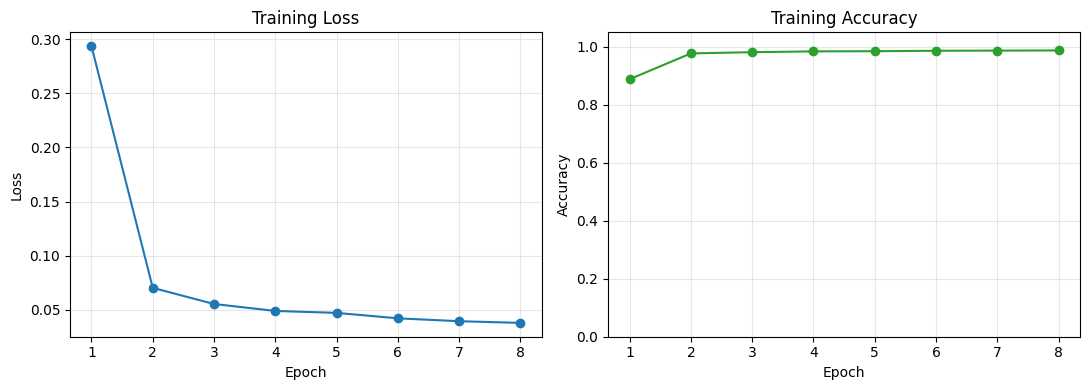

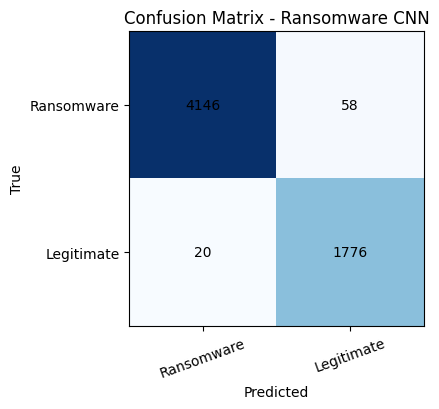

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(range(1, len(history["loss"]) + 1), history["loss"], marker="o", label="loss")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(history["train_acc"]) + 1), history["train_acc"], marker="o", color="tab:green", label="train_acc")
axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(4.8, 4.2))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Ransomware CNN")
plt.xticks([0, 1], [label_name_map[0], label_name_map[1]], rotation=20)
plt.yticks([0, 1], [label_name_map[0], label_name_map[1]])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## 十三、实验2结果解读

- 如果 `Ransomware` 的 recall 较高，说明模型能够覆盖大部分勒索软件样本，漏报风险较低。
- 如果合法软件被大量预测成勒索软件，说明误报较高，需要进一步做特征筛选、阈值调节或代价敏感训练。
- 默认 profile 会限制样本量和训练轮次，方便先跑通流程；正式记录结果时请同时说明样本规模和运行后端。


## 十四、MindSpore 与 CANN 的作用

MindSpore 在本节中负责 CNN 网络定义、数据集封装、训练循环和 checkpoint 保存；当后端切换为 Ascend 时，CANN 会承担卷积、归一化、矩阵计算等算子的编译与调度，加速训练和推理。


## 结论

完成本节后，你已经从 PE 静态特征数据出发，完成了预处理、CNN 输入组织、MindSpore 训练、测试评估和结果保存。阅读结果时不要只看总体准确率，还要重点关注勒索软件召回率和混淆矩阵。
